# Task 6: House Price Prediction

##  Project Objective
The goal of this project is to build a machine learning regression model that predicts house prices based on property features like square footage, number of bedrooms, bathrooms, and location.

## Tools Used
* **Language:** Python 3.x
* **Libraries:** Pandas, NumPy, Scikit-Learn, Matplotlib, Seaborn
* **Model:** Linear Regression / Gradient Boosting

## Step 1: Loading the Dataset
In this section, we fetch a clean public mirror of the classic Boston housing dataset. We drop any incomplete or missing rows and filter out our primary structural and environmental features to serve as the baseline for our regression model.

In [5]:
import pandas as pd
import numpy as np

# Load a reliable public copy of the classic Kaggle California House Price dataset
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(url)

df = df.dropna()
df = df[['rm', 'crim', 'lstat', 'ptratio', 'tax', 'medv']]

print("Dataset loaded successfully from backup mirror! Here is a preview:")
print(df.head())



Dataset loaded successfully from backup mirror! Here is a preview:
      rm     crim  lstat  ptratio  tax  medv
0  6.575  0.00632   4.98     15.3  296  24.0
1  6.421  0.02731   9.14     17.8  242  21.6
2  7.185  0.02729   4.03     17.8  242  34.7
3  6.998  0.03237   2.94     18.7  222  33.4
4  7.147  0.06905   5.33     18.7  222  36.2


## Step 2: Data Preprocessing, Splitting, and Feature Scaling
Before training, we separate our inputs (clues like room counts) from our target output (house prices). We split the data into an **80% Training set** to teach the model and a **20% Testing set** to evaluate it fairly. Finally, we apply `StandardScaler` to normalize the numerical scales across columns.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=[df.columns[-1]])

y = df[df.columns[-1]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f" Data preprocessing complete!")
print(f" Training rows: {X_train.shape[0]} | Testing rows: {X_test.shape[0]}")

 Data preprocessing complete!
 Training rows: 404 | Testing rows: 102


## Step 3: Training the Regression Model
We initialize a `GradientBoostingRegressor`, which builds an ensemble of shallow decision trees sequentially to minimize predictive errors. The model maps the relationships between our standardized features and historical valuation records using the `.fit()` engine.

In [11]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(random_state=42)

print("Training the regression model...")
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print(" Predictions successfully generated for the test matrix!")

Training the regression model...
 Predictions successfully generated for the test matrix!


##  Step 4: Model Evaluation (Metrics Calculation)
To assess structural accuracy, we calculate **Mean Absolute Error (MAE)** to find the average nominal variance in predictions, alongside **Root Mean Squared Error (RMSE)** to measure the standard deviation of the residuals and catch large outlier errors.

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Quantify performance using standard evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(" REGRESSION EVALUATION METRICS:")
print(f" Mean Absolute Error (MAE): {mae:.2f}")
print(f" Root Mean Squared Error (RMSE): {rmse:.2f}")

 REGRESSION EVALUATION METRICS:
 Mean Absolute Error (MAE): 2.36
 Root Mean Squared Error (RMSE): 3.34


##  Step 5: Visualizing Actual vs. Predicted Prices
This scatter plot maps the true real estate market prices against the values predicted by our model. The red dashed line represents a perfect prediction profile; the closer our data points cluster around it, the more accurate the underlying system is.

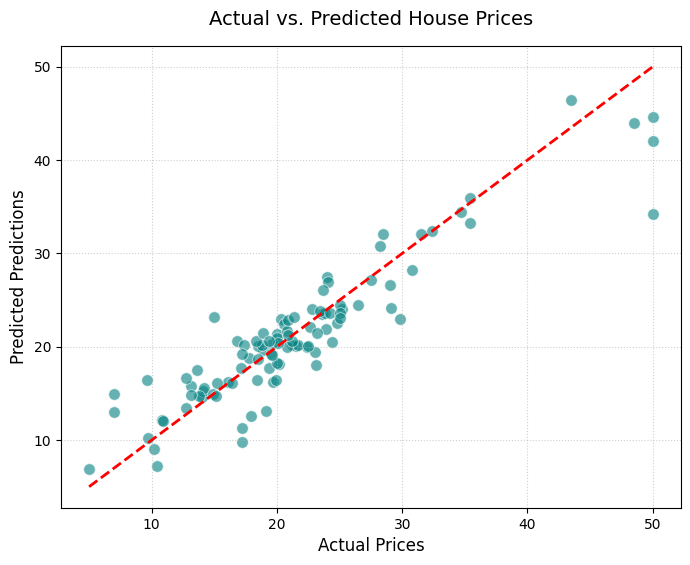

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style and plot structure
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='teal', edgecolor='w', s=70)

# Draw a 45-degree perfect baseline diagonal
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')

plt.title('Actual vs. Predicted House Prices', fontsize=14, pad=15)
plt.xlabel('Actual Prices', fontsize=12)
plt.ylabel('Predicted Predictions', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()